# **Dimitris Ntaoulzis 5311**

# *Hand Sign Representation Learning, Clustering and Generative Modeling*

In [26]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, TensorDataset
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.decomposition import PCA




## 2. Data Preprocessing

The following preprocessing steps were applied to the dataset:

### 2.1 Data Loading
The dataset was loaded from the CSV file using **pandas**. Each row contains 
a label and 784 pixel values representing a 28×28 grayscale image.

### 2.2 Normalization
Pixel values were normalized by dividing by 255, scaling them from the 
range [0, 255] to [0, 1]. This step is crucial for:
- Ensuring all features are on the same scale
- Improving training speed and stability

### 2.3 Train/Validation Split
The 27,455 training samples were split into:
- **Training set: 80%** → 21,964 samples
- **Validation set: 20%** → 5,491 samples

The split was performed using **stratified sampling** (`stratify=y`) to ensure 
proportional class representation in both sets.

In [ ]:
# Load dataset from CSV
df = pd.read_csv('sign_mnist_train.csv')

# Separate features (X) and labels (y)
# X: 784 pixel values per image, y: class label (0-24)
X = df.drop('label', axis=1)
y = df['label']

print(df.shape)
print(df.head())


(27455, 785)
   label  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  pixel8  \
0      3     107     118     127     134     139     143     146     150   
1      6     155     157     156     156     156     157     156     158   
2      2     187     188     188     187     187     186     187     188   
3      2     211     211     212     212     211     210     211     210   
4     13     164     167     170     172     176     179     180     184   

   pixel9  ...  pixel775  pixel776  pixel777  pixel778  pixel779  pixel780  \
0     153  ...       207       207       207       207       206       206   
1     158  ...        69       149       128        87        94       163   
2     187  ...       202       201       200       199       198       199   
3     210  ...       235       234       233       231       230       226   
4     185  ...        92       105       105       108       133       163   

   pixel781  pixel782  pixel783  pixel784  
0       206      

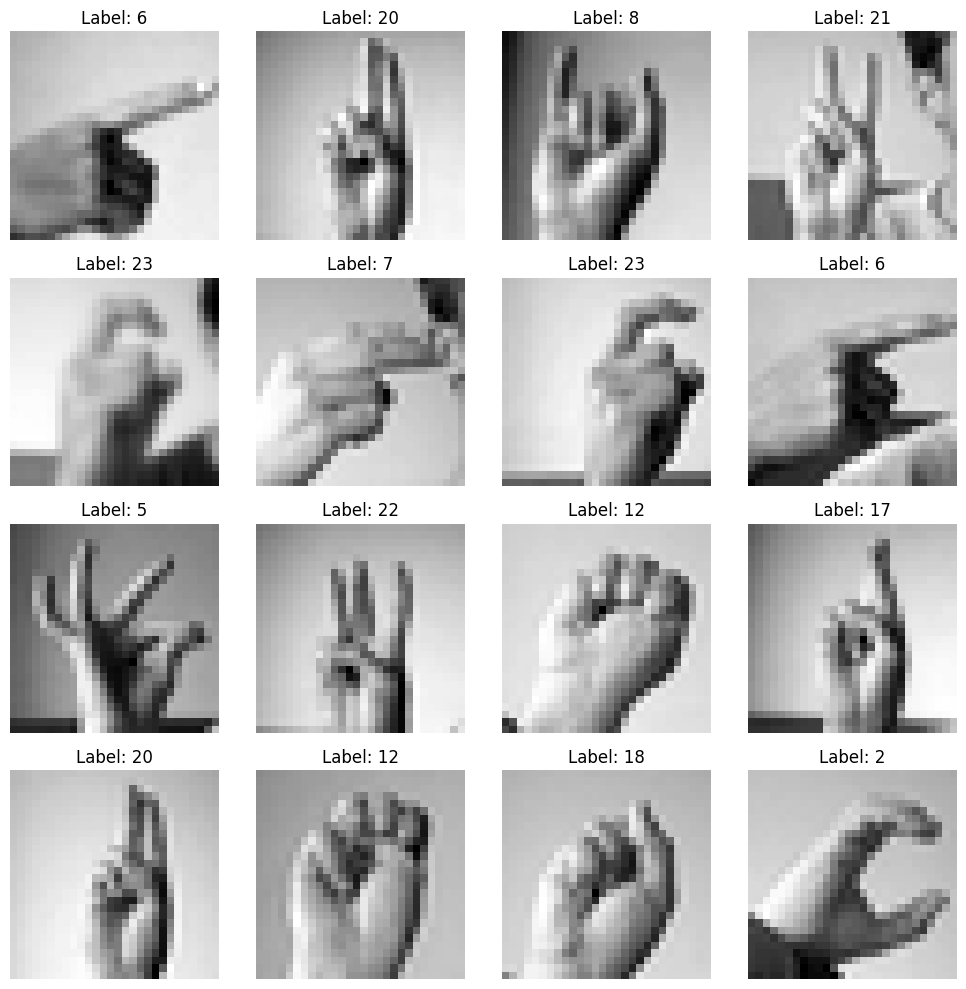

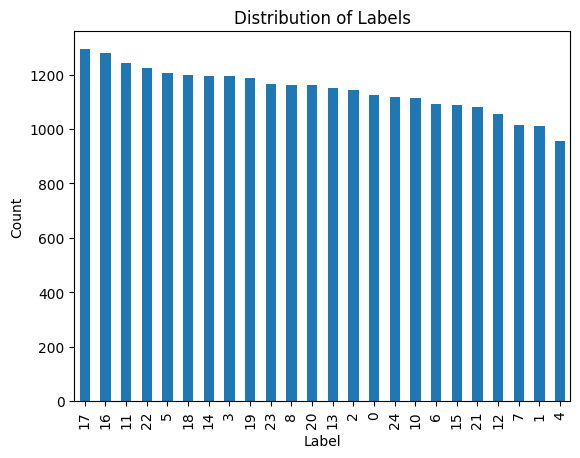

In [ ]:
# Visualize 16 random samples from the dataset
# Each image is reshaped from (784,) to (28, 28) for display
fig, axes = plt.subplots(4, 4, figsize=(10, 10)) # 4x4 grid για 16 εικόνες
for i in range(4):
    for j in range(4):
        #random index
        idx = np.random.randint(0, len(X))
        image = X.iloc[idx].values.reshape(28, 28)
        # .values → μετατροπή από pandas σε numpy array
        # .reshape(28, 28) → από (784,) σε (28, 28)
        axes[i, j].imshow(image, cmap='gray')
        axes[i, j].set_title(f"Label: {y.iloc[idx]}")
        axes[i, j].axis('off') #Hide axes
plt.tight_layout() #Για να μην επικαλύπτονται οι εικόνες
plt.show()

y.value_counts().plot(kind='bar') #Πόσες φορές εμφανίζεται κάθε label
plt.title('Distribution of Labels')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()


In [ ]:
# Stratified split: 80% train, 20% validation
# stratify=y ensures proportional class representation
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=0, stratify=y) #Διαχωρισμός σε train και test set

print(X_train.shape)
print(X_val.shape)
print(y_train.shape)
print(y_val.shape)


(21964, 784)
(5491, 784)
(21964,)
(5491,)


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


In [ ]:
# Reshape to (N, 1, 28, 28): N samples, 1 channel (grayscale), 28x28 pixels
# Normalize to [0,1] by dividing by 255
# We use the full dataset (X) for the Autoencoder since it's unsupervised
X_tensor = torch.tensor(X.values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
y_tensor = torch.tensor(y.values, dtype=torch.long)

# Dataset και DataLoader
dataset = TensorDataset(X_tensor, y_tensor)
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

## Part A - CNN Autoencoder

### Architecture
The CNN Autoencoder consists of:
- **Encoder:** 2 Conv layers (32, 64 filters) + MaxPool → Flatten → 
  Linear(128) → Linear(64) → Linear(32) → Latent Space(M)
- **Decoder:** Linear(32) → Linear(64) → Linear(128) → Linear(3136) → 
  Reshape → 2 ConvTranspose layers → Output(1, 28, 28)

Three latent dimensions are tested: **M = {2, 10, 50}**

In [ ]:
class CNNAutoencoder(nn.Module):
    def __init__(self, latent_dim):
        super(CNNAutoencoder, self).__init__()

        # === ENCODER ===
        self.encoder_conv = nn.Sequential(
            # Conv layer 1: 1 -> 32 filters
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), #28x28 -> 14x14

            # Conv layer 2: 32 -> 64 filters
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2), #14x14 -> 7x7
        )

        # Flatten -> Linear layers
        self.encoder_fc = nn.Sequential(
            nn.Flatten(), #64*7*7 = 3136
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim) #Latent space (M)
        )

        # === DECODER ===
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3136), #64*7*7
            nn.ReLU()
        )

        self.decoder_conv = nn.Sequential(
            # ConvTranspose layer 1: 64 -> 32 filters
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2), #7x7 -> 14x14
            nn.ReLU(),

            # ConvTranspose layer 2: 32 -> 1 filter
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2), #14x14 -> 28x28
            nn.Sigmoid() #Για να έχουμε έξοδο μεταξύ 0 και 1
        )

    def forward(self, x):
        # Encoding: Conv layers extract spatial features
        x = self.encoder_conv(x)
        latent = self.encoder_fc(x)

        # Decoding: expand from latent space back to image
        x = self.decoder_fc(latent)
        # Reshape for ConvTranspose layers: (batch, 64, 7, 7)
        x = x.reshape(-1, 64, 7, 7) #Από (batch_size, 3136) σε (batch_size, 64, 7, 7)
        x = self.decoder_conv(x)
        return x, latent        

In [ ]:
# MSELoss: measures pixel-wise reconstruction error
# Input = Target: the goal is to reconstruct the input image
# _ : labels not needed (unsupervised learning)
def train_autoencoder(model, dataloader, epochs=20, lr=0.001):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for images, _ in dataloader: # _ γιατί δεν χρειαζόμαστε labels
            images = images.to(device)

            # Forward pass
            reconstructed, latent = model(images)

            # Loss: MSE μεταξύ αρχικής και ανακατασκευασμένης εικόνας
            loss = criterion(reconstructed, images)

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.6f}")
    
    return model

In [ ]:
# Note: models not saved separately here see nextcell for proper training
for M in [2, 10, 50]:
    print(f"\nTraining autoencoder with latent dimension M={M}")
    model = CNNAutoencoder(latent_dim=M)
    model = train_autoencoder(model, dataloader, epochs=20)


Training autoencoder with latent dimension M=2
Epoch [1/20], Loss: 0.023921
Epoch [2/20], Loss: 0.018357
Epoch [3/20], Loss: 0.017555
Epoch [4/20], Loss: 0.016950
Epoch [5/20], Loss: 0.016575
Epoch [6/20], Loss: 0.016147
Epoch [7/20], Loss: 0.015865
Epoch [8/20], Loss: 0.015548
Epoch [9/20], Loss: 0.015238
Epoch [10/20], Loss: 0.015159
Epoch [11/20], Loss: 0.015055
Epoch [12/20], Loss: 0.014861
Epoch [13/20], Loss: 0.014860
Epoch [14/20], Loss: 0.014509
Epoch [15/20], Loss: 0.014277
Epoch [16/20], Loss: 0.014380
Epoch [17/20], Loss: 0.014341
Epoch [18/20], Loss: 0.013933
Epoch [19/20], Loss: 0.013958
Epoch [20/20], Loss: 0.013899

Training autoencoder with latent dimension M=10
Epoch [1/20], Loss: 0.022342
Epoch [2/20], Loss: 0.014144
Epoch [3/20], Loss: 0.011897
Epoch [4/20], Loss: 0.010410
Epoch [5/20], Loss: 0.009434
Epoch [6/20], Loss: 0.008700
Epoch [7/20], Loss: 0.008116
Epoch [8/20], Loss: 0.007553
Epoch [9/20], Loss: 0.007099
Epoch [10/20], Loss: 0.006754
Epoch [11/20], Loss: 

# *Παρατηρήσεις:*

- Όσο **μεγαλύτερο** το M → **μικρότερο** loss — λογικό γιατί με περισσότερες διαστάσεις ο Autoencoder μπορεί να αποθηκεύσει περισσότερη πληροφορία
- `M=2` έχει το μεγαλύτερο loss — πολύ δύσκολο να συμπιέσεις 784 pixels σε μόλις 2 αριθμούς
- `M=10` vs `M=50` — η διαφορά είναι μικρή, άρα τα 10 dimensions είναι αρκετά για να αποτυπώσουν τα βασικά χαρακτηριστικά

In [ ]:
# Αποθήκευση κάθε μοντέλου ξεχωριστά
autoencoders = {}
torch.manual_seed(42)
np.random.seed(42)

for M in [2, 10, 50]:
    print(f"\n=== Training Autoencoder with M={M} ===")
    model = CNNAutoencoder(latent_dim=M)
    model = train_autoencoder(model, dataloader, epochs=20)
    autoencoders[M] = model  # Αποθήκευση


=== Training Autoencoder with M=2 ===
Epoch [1/20], Loss: 0.022607
Epoch [2/20], Loss: 0.018146
Epoch [3/20], Loss: 0.017595
Epoch [4/20], Loss: 0.017202
Epoch [5/20], Loss: 0.016964
Epoch [6/20], Loss: 0.016563
Epoch [7/20], Loss: 0.016421
Epoch [8/20], Loss: 0.016089
Epoch [9/20], Loss: 0.016101
Epoch [10/20], Loss: 0.017398
Epoch [11/20], Loss: 0.016686
Epoch [12/20], Loss: 0.016303
Epoch [13/20], Loss: 0.015912
Epoch [14/20], Loss: 0.015976
Epoch [15/20], Loss: 0.015655
Epoch [16/20], Loss: 0.015606
Epoch [17/20], Loss: 0.015381
Epoch [18/20], Loss: 0.015515
Epoch [19/20], Loss: 0.015258
Epoch [20/20], Loss: 0.015019

=== Training Autoencoder with M=10 ===
Epoch [1/20], Loss: 0.021969
Epoch [2/20], Loss: 0.013921
Epoch [3/20], Loss: 0.011832
Epoch [4/20], Loss: 0.010345
Epoch [5/20], Loss: 0.009363
Epoch [6/20], Loss: 0.008495
Epoch [7/20], Loss: 0.007803
Epoch [8/20], Loss: 0.007213
Epoch [9/20], Loss: 0.006759
Epoch [10/20], Loss: 0.006386
Epoch [11/20], Loss: 0.006064
Epoch [12

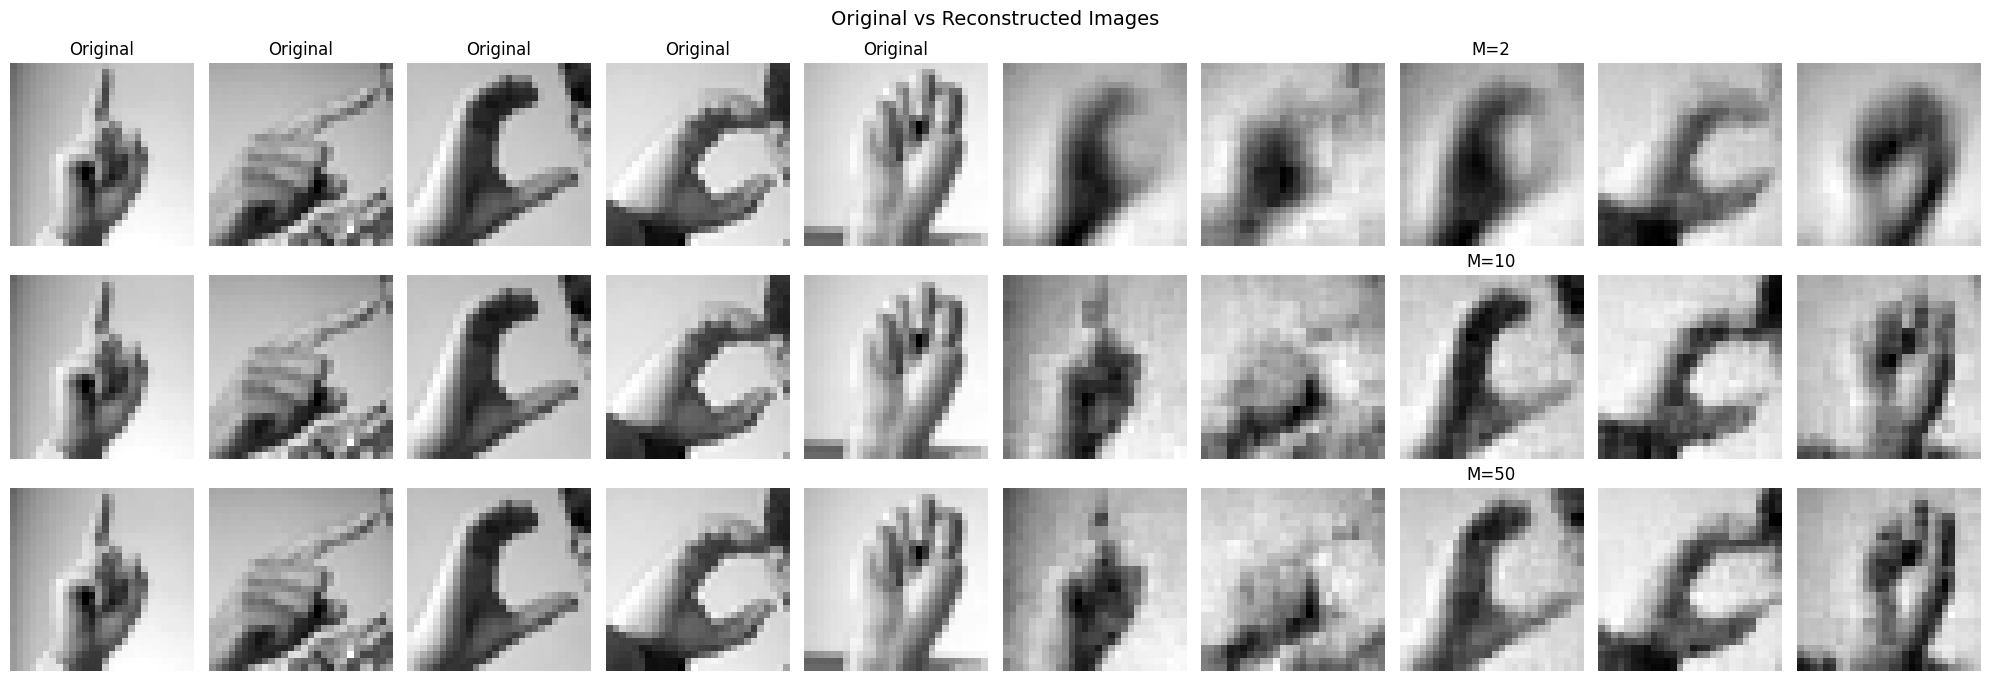

In [11]:
fig, axes = plt.subplots(3, 10, figsize=(20, 7))

for row, M in enumerate([2, 10, 50]):
    model = autoencoders[M]
    model.eval()
    
    with torch.no_grad():
        sample = X_tensor[:5].to(device)
        reconstructed, _ = model(sample)
    
    for col in range(5):
        # Αρχική εικόνα
        axes[row, col].imshow(sample[col].cpu().squeeze(), cmap='gray')
        axes[row, col].set_title(f'Original' if row == 0 else '')
        axes[row, col].axis('off')
        
        # Ανακατασκευασμένη εικόνα
        axes[row, col+5].imshow(reconstructed[col].cpu().squeeze(), cmap='gray')
        axes[row, col+5].set_title(f'M={M}' if col == 2 else '')
        axes[row, col+5].axis('off')

plt.suptitle('Original vs Reconstructed Images', fontsize=14)
plt.tight_layout()
plt.show()

# *Παρατηρήσεις:*
**`M=2`**:

- Οι εικόνες είναι πολύ θολές και χάνουν πολλές λεπτομέρειες

**`M=10`**:

- Σαφώς καλύτερες από M=2
- Διακρίνονται τα βασικά σχήματα των χεριών
- Κάποιες λεπτομέρειες χάνονται ακόμα

**`M=50`**:

- Πιο κοντά στις αρχικές εικόνες
- Διακρίνονται περισσότερες λεπτομέρειες
- Ακόμα όχι τέλειες λόγω της συμπίεσης

## A1 - Classification in Latent Space

Using the best model from Assignment 1 (Random Forest, n_estimators=200) 
to classify data in the compressed latent space instead of the original 784-dim space.

**Pipeline:**
`Image (784) → CNN Encoder → Latent Space (M) → Random Forest → Prediction`

In [ ]:
# Extract latent vectors using only the Encoder part
# model.eval(): disable dropout/batchnorm for inference
# torch.no_grad(): no gradient computation needed for inference
def get_latent_representations(model, X_tensor):
    model.eval()
    with torch.no_grad():
        _, latent = model(X_tensor.to(device))
    return latent.cpu().numpy()

In [13]:
latent_representations = {}
for M in [2, 10, 50]:
    latent_representations[M] = get_latent_representations(autoencoders[M], X_tensor)
    print(f"M={M}: shape = {latent_representations[M].shape}")

M=2: shape = (27455, 2)
M=10: shape = (27455, 10)
M=50: shape = (27455, 50)


In [14]:
# Μετατροπή X_train και X_val σε tensors
X_train_tensor = torch.tensor(X_train.values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0
X_val_tensor = torch.tensor(X_val.values, dtype=torch.float32).reshape(-1, 1, 28, 28) / 255.0

for M in [2, 10, 50]:
    print(f"\n=== Classification in Latent Space M={M} ===")
    
    # Εξαγωγή latent representations για train και val ξεχωριστά
    X_lat_train = get_latent_representations(autoencoders[M], X_train_tensor)
    X_lat_val = get_latent_representations(autoencoders[M], X_val_tensor)
    
    # Εκπαίδευση Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
    rf.fit(X_lat_train, y_train)
    y_pred = rf.predict(X_lat_val)
    
    # Metrics
    acc = accuracy_score(y_val, y_pred)
    prec = precision_score(y_val, y_pred, average='weighted')
    rec = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")


=== Classification in Latent Space M=2 ===
Accuracy:  0.3926
Precision: 0.3912
Recall:    0.3926
F1 Score:  0.3915

=== Classification in Latent Space M=10 ===
Accuracy:  0.9701
Precision: 0.9702
Recall:    0.9701
F1 Score:  0.9701

=== Classification in Latent Space M=50 ===
Accuracy:  0.9953
Precision: 0.9953
Recall:    0.9953
F1 Score:  0.9953


# Συμπέρασμα:
- Ο CNN Autoencoder μαθαίνει πιο χρήσιμες αναπαραστάσεις από τα raw pixels, με μόλις 10 dimensions επιτυγχάνει καλύτερη ταξινόμηση από ό,τι με 784 raw pixels.

## A2 - Clustering in Latent Space

Two clustering algorithms are applied to the latent representations:
1. **K-means** with Silhouette Score to find optimal K*
2. **Hierarchical Agglomerative Clustering** with dendrogram visualization

Linkage methods tested: Ward, Complete, Average
Distance metric: Euclidean


=== K-means for M=2 ===
K=2, Silhouette Score: 0.4803
K=3, Silhouette Score: 0.4571
K=4, Silhouette Score: 0.3937
K=5, Silhouette Score: 0.4221
K=6, Silhouette Score: 0.3743
K=7, Silhouette Score: 0.3811
K=8, Silhouette Score: 0.3774
K=9, Silhouette Score: 0.3908
K=10, Silhouette Score: 0.3820
K=11, Silhouette Score: 0.3813
K=12, Silhouette Score: 0.3819
K=13, Silhouette Score: 0.3762
K=14, Silhouette Score: 0.3787
K=15, Silhouette Score: 0.3696
K=16, Silhouette Score: 0.3704
K=17, Silhouette Score: 0.3655
K=18, Silhouette Score: 0.3612
K=19, Silhouette Score: 0.3681
K=20, Silhouette Score: 0.3721
K=21, Silhouette Score: 0.3752
K=22, Silhouette Score: 0.3730
K=23, Silhouette Score: 0.3683
K=24, Silhouette Score: 0.3691
K=25, Silhouette Score: 0.3716
K=26, Silhouette Score: 0.3648
K=27, Silhouette Score: 0.3745
K=28, Silhouette Score: 0.3684
K=29, Silhouette Score: 0.3791
K=30, Silhouette Score: 0.3525

=== K-means for M=10 ===
K=2, Silhouette Score: 0.2451
K=3, Silhouette Score: 0.228

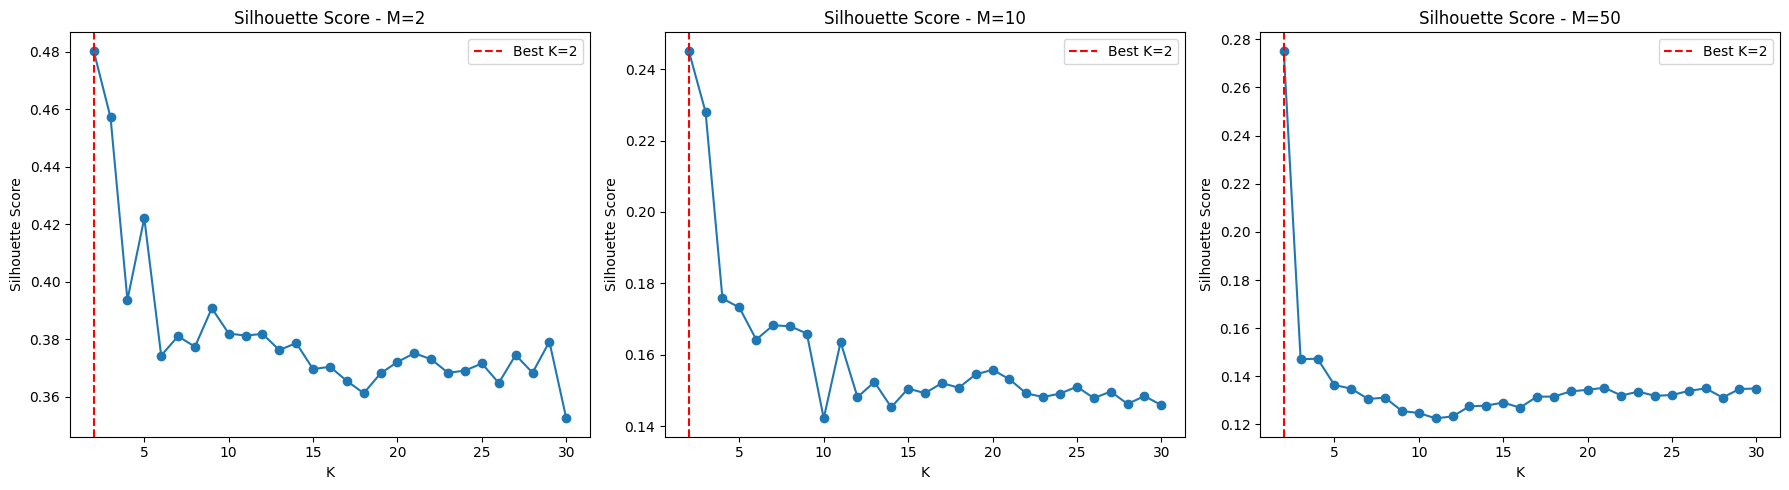

In [ ]:
# Silhouette Score range: [-1, 1]
# +1: well-separated clusters, 0: overlapping, -1: wrong cluster
# n_init>10: multiple random initializations for stability
# Αποθήκευση αποτελεσμάτων
silhouette_scores = {2: [], 10: [], 50: []}
K_range = range(2, 31)

for M in [2, 10, 50]:
    print(f"\n=== K-means for M={M} ===")
    X_lat = latent_representations[M]
    
    for K in K_range:
        kmeans = KMeans(n_clusters=K, n_init=15, random_state=42)
        labels = kmeans.fit_predict(X_lat)
        score = silhouette_score(X_lat, labels)
        silhouette_scores[M].append(score)
        print(f"K={K}, Silhouette Score: {score:.4f}")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, M in enumerate([2, 10, 50]):
    axes[idx].plot(K_range, silhouette_scores[M], marker='o')
    best_K = list(K_range)[silhouette_scores[M].index(max(silhouette_scores[M]))]
    axes[idx].axvline(x=best_K, color='red', linestyle='--', label=f'Best K={best_K}')
    axes[idx].set_title(f'Silhouette Score - M={M}')
    axes[idx].set_xlabel('K')
    axes[idx].set_ylabel('Silhouette Score')
    axes[idx].legend()

plt.tight_layout()
plt.show()

# Γιατί `M=10` και `M=50` έχουν χαμηλό Silhouette Score:
1) **Curse of Dimensionality**:
Όσο αυξάνουν οι διαστάσεις, οι αποστάσεις μεταξύ των σημείων γίνονται πιο ομοιόμορφες — δηλαδή όλα τα σημεία φαίνονται εξίσου "μακριά" μεταξύ τους. Αυτό κάνει τον διαχωρισμό σε clusters πιο δύσκολο.

2) **M=2**:
Με μόλις 2 διαστάσεις τα δεδομένα είναι πιο συμπιεσμένα και οι clusters φαίνονται πιο ξεκάθαρα — αλλά αυτό δεν σημαίνει ότι είναι πιο χρήσιμο για ταξινόμηση.

3) **Τα δεδομένα δεν έχουν φυσικά clusters**:
Με 24 κλάσεις που μοιάζουν οπτικά μεταξύ τους, ο latent space δεν σχηματίζει ξεκάθαρα διαχωρισμένες ομάδες.

*Συμπέρασμα:*
Υψηλό Silhouette Score ≠ καλή αναπαράσταση. Το M=50 είναι καλύτερο για ταξινόμηση (99.5%) αλλά χειρότερο για clustering.


=== Hierarchical Clustering for M=2 ===


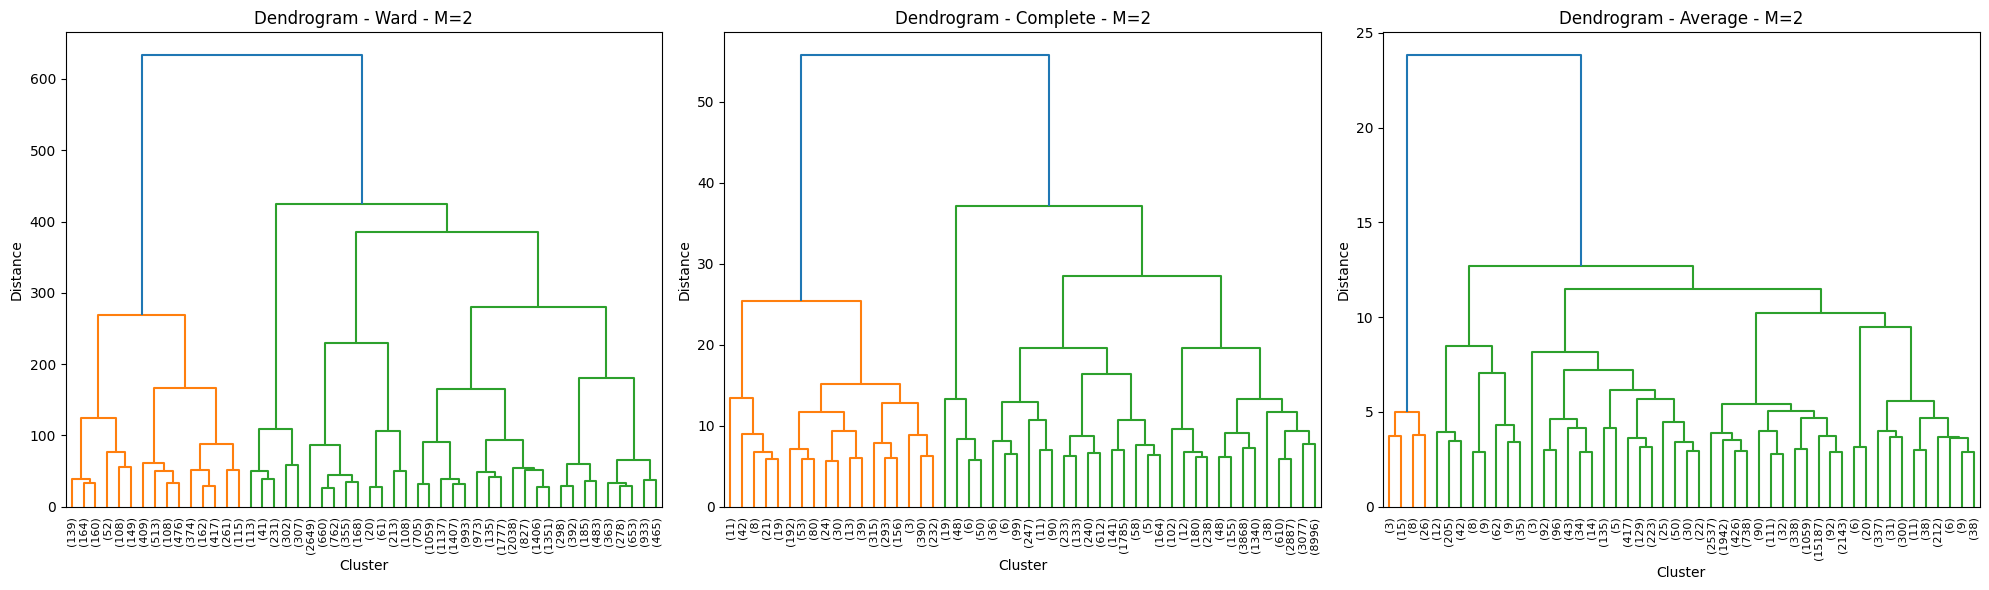


=== Hierarchical Clustering for M=10 ===


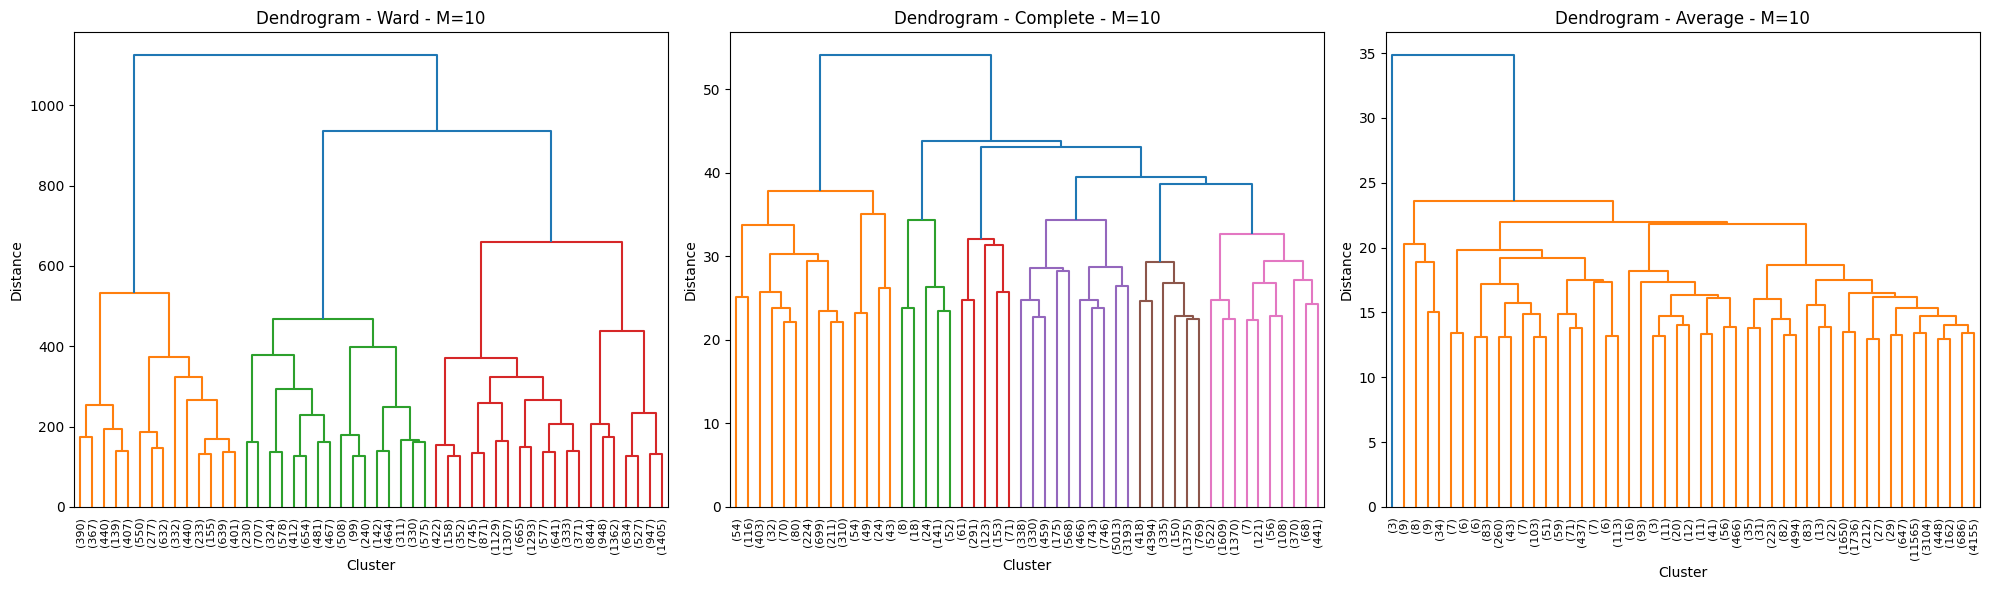


=== Hierarchical Clustering for M=50 ===


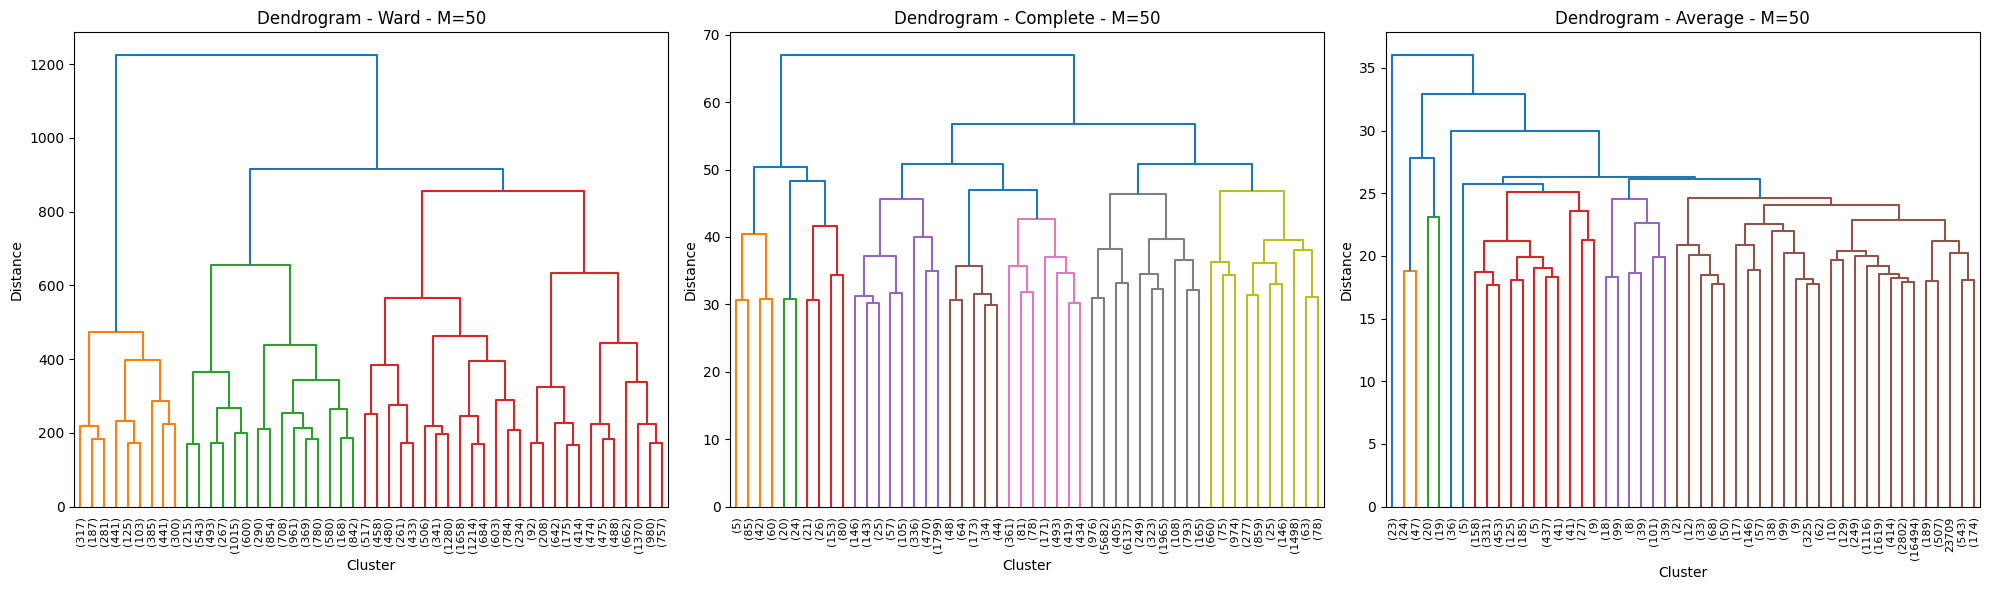

In [16]:
for M in [2, 10, 50]:
    print(f"\n=== Hierarchical Clustering for M={M} ===")
    X_lat = latent_representations[M]
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    
    for idx, linkage_method in enumerate(['ward', 'complete', 'average']):
        # Υπολογισμός linkage matrix
        Z = linkage(X_lat, method=linkage_method, metric='euclidean')
        
        # Truncated dendrogram (τελευταία 50 merges)
        dendrogram(Z, ax=axes[idx], truncate_mode='lastp', p=50,
                  leaf_rotation=90, leaf_font_size=8)
        axes[idx].set_title(f'Dendrogram - {linkage_method.capitalize()} - M={M}')
        axes[idx].set_xlabel('Cluster')
        axes[idx].set_ylabel('Distance')
    
    plt.tight_layout()
    plt.show()

# Dendrograms:

- **Ward**: Πιο ισορροπημένη δομή — τα clusters έχουν παρόμοια μεγέθη
- **Complete**: Πιο "πλατύ" δέντρο — τείνει να φτιάχνει compact clusters
- **Average**: Πιο "ασύμμετρο" — ένα μεγάλο cluster κυριαρχεί

In [17]:
best_K = {2: 2, 10: 2, 50: 3}  # Από τα αποτελέσματα του Silhouette

for M in [2, 10, 50]:
    print(f"\n=== Comparison for M={M}, K*={best_K[M]} ===")
    X_lat = latent_representations[M]
    K = best_K[M]
    
    # K-means
    kmeans = KMeans(n_clusters=K, n_init=15, random_state=42)
    kmeans_labels = kmeans.fit_predict(X_lat)
    kmeans_score = silhouette_score(X_lat, kmeans_labels)
    
    # Hierarchical (Ward)
    agg = AgglomerativeClustering(n_clusters=K, linkage='ward')
    agg_labels = agg.fit_predict(X_lat)
    agg_score = silhouette_score(X_lat, agg_labels)
    
    print(f"K-means Silhouette Score:      {kmeans_score:.4f}")
    print(f"Hierarchical Silhouette Score: {agg_score:.4f}")


=== Comparison for M=2, K*=2 ===
K-means Silhouette Score:      0.4803
Hierarchical Silhouette Score: 0.5087

=== Comparison for M=10, K*=2 ===
K-means Silhouette Score:      0.2451
Hierarchical Silhouette Score: 0.2438

=== Comparison for M=50, K*=3 ===
K-means Silhouette Score:      0.1471
Hierarchical Silhouette Score: 0.0981


### K-means vs Hierarchical Comparison

| M | K* | K-means | Hierarchical |
|---|---|---------|--------------|
| 2 | 2 | 0.4803 | **0.5087** |
| 10 | 2 | **0.2451** | 0.2438 |
| 50 | 2 | **0.1471** | 0.0981 |

- For **M=2**: Hierarchical slightly better
- For **M=10, M=50**: K-means slightly better
- Overall scores are low due to the high overlap between ASL classes in latent space

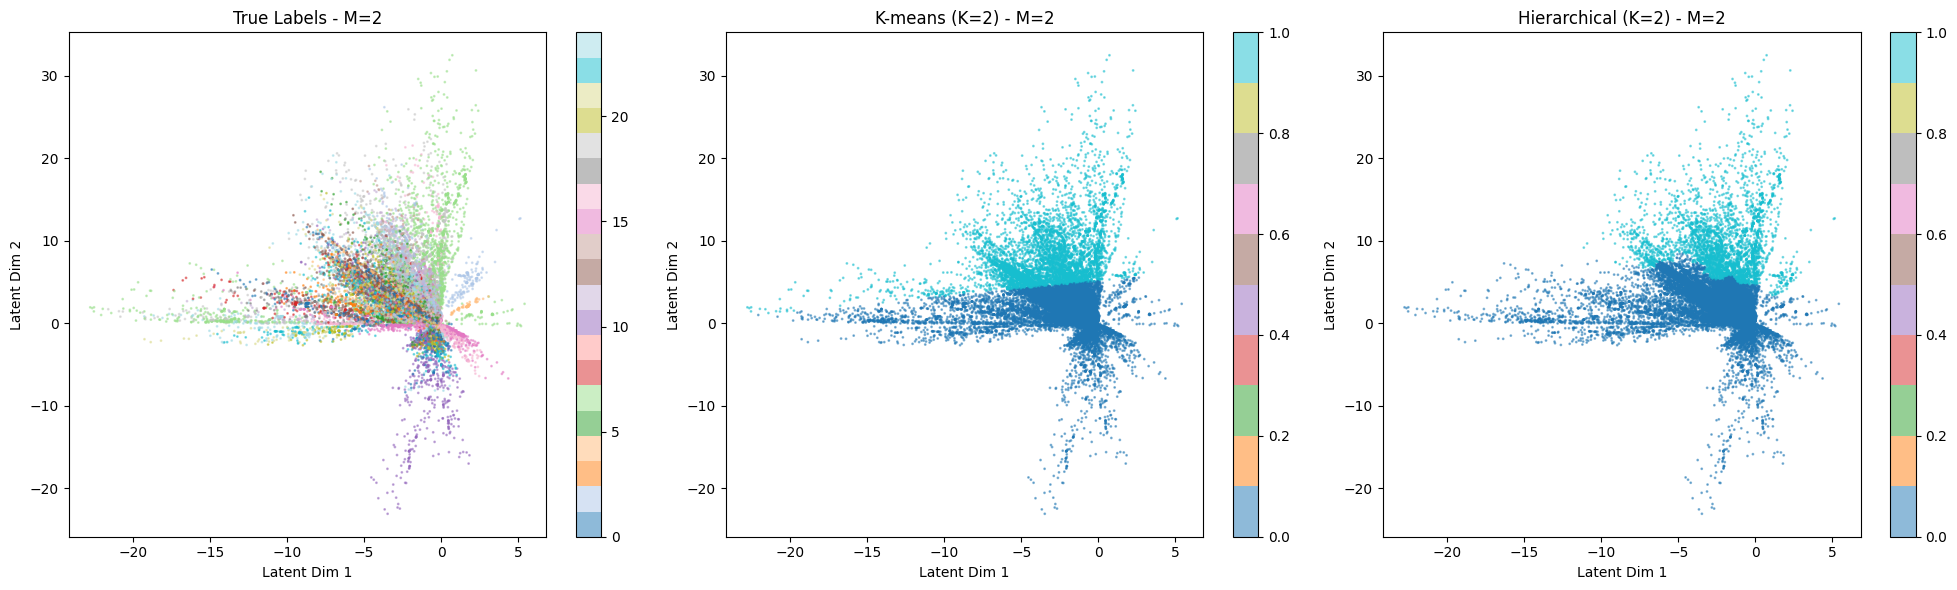

In [18]:
LABEL_TO_LETTER = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H', 8:'I', 9:'K',
    10:'L', 11:'M', 12:'N', 13:'O', 14:'P', 15:'Q', 16:'R', 17:'S',
    18:'T', 19:'U', 20:'V', 21:'W', 22:'X', 23:'Y'
}

X_2d = latent_representations[2]
y_np = y.values

# K-means και Hierarchical labels για M=2
kmeans_2d = KMeans(n_clusters=2, n_init=15, random_state=42)
kmeans_labels_2d = kmeans_2d.fit_predict(X_2d)

agg_2d = AgglomerativeClustering(n_clusters=2, linkage='ward')
agg_labels_2d = agg_2d.fit_predict(X_2d)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Plot 1: Πραγματικές κλάσεις
scatter1 = axes[0].scatter(X_2d[:, 0], X_2d[:, 1], 
                            c=y_np, cmap='tab20', s=1, alpha=0.5)
axes[0].set_title('True Labels - M=2')
axes[0].set_xlabel('Latent Dim 1')
axes[0].set_ylabel('Latent Dim 2')
plt.colorbar(scatter1, ax=axes[0])

# Plot 2: K-means clusters
scatter2 = axes[1].scatter(X_2d[:, 0], X_2d[:, 1],
                            c=kmeans_labels_2d, cmap='tab10', s=1, alpha=0.5)
axes[1].set_title(f'K-means (K=2) - M=2')
axes[1].set_xlabel('Latent Dim 1')
axes[1].set_ylabel('Latent Dim 2')
plt.colorbar(scatter2, ax=axes[1])

# Plot 3: Hierarchical clusters
scatter3 = axes[2].scatter(X_2d[:, 0], X_2d[:, 1],
                            c=agg_labels_2d, cmap='tab10', s=1, alpha=0.5)
axes[2].set_title(f'Hierarchical (K=2) - M=2')
axes[2].set_xlabel('Latent Dim 1')
axes[2].set_ylabel('Latent Dim 2')
plt.colorbar(scatter3, ax=axes[2])

plt.tight_layout()
plt.show()

## Part B - Generative Models

### B1 - Variational Autoencoder (VAE)
Unlike the standard AE, the VAE encoder outputs a **distribution** N(μ, σ²) 
instead of a single point. Sampling is done via the **reparameterization trick**:
`z = μ + σ * ε, where ε ~ N(0,1)`

### Loss Function
`Loss = Reconstruction Loss (MSE) + KL Divergence`
- **Reconstruction Loss:** How well the image is reconstructed
- **KL Divergence:** Forces the latent space to follow N(0,I)

In [19]:
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        super(VAE, self).__init__()
        
        # ============ ENCODER ============
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 28x28 → 14x14
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)   # 14x14 → 7x7
        )
        
        self.encoder_fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3136, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        # Δύο ξεχωριστά layers για mean και log_var
        self.fc_mean = nn.Linear(32, latent_dim)
        self.fc_log_var = nn.Linear(32, latent_dim)
        
        # ============ DECODER ============
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3136),
            nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),  # 7x7 → 14x14
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),   # 14x14 → 28x28
            nn.Sigmoid()
        )
    
    def reparameterize(self, mean, log_var):
        # Reparameterization trick
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)  # Sample από N(0,1)
        return mean + epsilon * std
    
    def forward(self, x):
        # Encoding
        x = self.encoder_conv(x)
        x = self.encoder_fc(x)
        
        # Mean και log_var
        mean = self.fc_mean(x)
        log_var = self.fc_log_var(x)
        
        # Sampling με reparameterization trick
        z = self.reparameterize(mean, log_var)
        
        # Decoding
        x = self.decoder_fc(z)
        x = x.reshape(-1, 64, 7, 7)
        x = self.decoder_conv(x)
        
        return x, mean, log_var

In [ ]:
# reduction='sum': sum over all pixels and batch
# KL formula: -0.5 * sum(1 + log_var - mean² - exp(log_var))
# This encourages the latent distribution to be close to N(0,1)
def vae_loss(reconstructed, original, mean, log_var):
    # Reconstruction Loss (MSE)
    recon_loss = nn.MSELoss(reduction='sum')(reconstructed, original)
    
    # KL Divergence
    # Μετράει πόσο διαφέρει η κατανομή μας από N(0,1)
    kl_loss = -0.5 * torch.sum(1 + log_var - mean.pow(2) - log_var.exp())
    
    return recon_loss + kl_loss

In [21]:
def train_vae(model, dataloader, epochs=20, lr=0.001):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, _ in dataloader:
            images = images.to(device)
            
            # Forward pass
            reconstructed, mean, log_var = model(images)
            
            # Loss
            loss = vae_loss(reconstructed, images, mean, log_var)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.2f}")
    
    return model

# Εκπαίδευση VAE με M=2
torch.manual_seed(42)
print("=== Training VAE (M=2) ===")
vae = VAE(latent_dim=2)
vae = train_vae(vae, dataloader, epochs=20)

=== Training VAE (M=2) ===
Epoch 1/20, Loss: 1380.53
Epoch 2/20, Loss: 1277.17
Epoch 3/20, Loss: 1273.72
Epoch 4/20, Loss: 1208.79
Epoch 5/20, Loss: 1157.14
Epoch 6/20, Loss: 1145.33
Epoch 7/20, Loss: 1135.89
Epoch 8/20, Loss: 1131.09
Epoch 9/20, Loss: 1125.86
Epoch 10/20, Loss: 1123.50
Epoch 11/20, Loss: 1117.96
Epoch 12/20, Loss: 1115.01
Epoch 13/20, Loss: 1114.70
Epoch 14/20, Loss: 1108.64
Epoch 15/20, Loss: 1106.22
Epoch 16/20, Loss: 1102.57
Epoch 17/20, Loss: 1103.77
Epoch 18/20, Loss: 1097.61
Epoch 19/20, Loss: 1095.56
Epoch 20/20, Loss: 1098.19


### B2 - Conditional VAE (cVAE)
The cVAE conditions on the class label using a **one-hot vector** (24 dims).
The condition is concatenated:
- In the **Encoder**: after the flatten layer → `[flattened(3136) + one_hot(25)]`
- In the **Decoder**: with the latent vector z → `[z(2) + one_hot(25)]`

In [24]:
class cVAE(nn.Module):
    def __init__(self, latent_dim=2, num_classes=25):
        super(cVAE, self).__init__()
        self.num_classes = num_classes
        
        # ============ ENCODER ============
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        
        # +num_classes γιατί concatenate το one-hot με το flattened
        self.encoder_fc = nn.Sequential(
            nn.Linear(3136 + num_classes, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU()
        )
        
        self.fc_mean = nn.Linear(32, latent_dim)
        self.fc_log_var = nn.Linear(32, latent_dim)
        
        # ============ DECODER ============
        # +num_classes γιατί concatenate το one-hot με το z
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim + num_classes, 32),
            nn.ReLU(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 3136),
            nn.ReLU()
        )
        
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=2, stride=2),
            nn.Sigmoid()
        )
    
    def reparameterize(self, mean, log_var):
        std = torch.exp(0.5 * log_var)
        epsilon = torch.randn_like(std)
        return mean + epsilon * std
    
    def forward(self, x, labels):
        # One-hot encoding των labels
        one_hot = torch.zeros(labels.size(0), self.num_classes).to(x.device)
        one_hot.scatter_(1, labels.unsqueeze(1), 1)
        
        # Encoding
        x = self.encoder_conv(x)
        x = x.reshape(x.size(0), -1)  # Flatten
        
        # Concatenate με one-hot
        x = torch.cat([x, one_hot], dim=1)
        x = self.encoder_fc(x)
        
        mean = self.fc_mean(x)
        log_var = self.fc_log_var(x)
        z = self.reparameterize(mean, log_var)
        
        # Concatenate z με one-hot για τον Decoder
        z_cond = torch.cat([z, one_hot], dim=1)
        
        # Decoding
        x = self.decoder_fc(z_cond)
        x = x.reshape(-1, 64, 7, 7)
        x = self.decoder_conv(x)
        
        return x, mean, log_var

In [ ]:
def train_cvae(model, dataloader, epochs=20, lr=0.001):
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        
        for images, labels in dataloader:  # Τώρα χρειαζόμαστε και τα labels
            images = images.to(device)
            labels = labels.to(device)
            
            # Forward pass - περνάμε και labels
            reconstructed, mean, log_var = model(images, labels)
            
            # Ίδια loss function με τον VAE
            loss = vae_loss(reconstructed, images, mean, log_var)
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        
        avg_loss = total_loss / len(dataloader)
        print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.2f}")
    
    return model

# Εκπαίδευση cVAE
torch.manual_seed(42)
print("=== Training cVAE (M=2) ===")
cvae = cVAE(latent_dim=2, num_classes=25)
cvae = train_cvae(cvae, dataloader, epochs=20)

=== Training cVAE (M=2) ===
Epoch 1/20, Loss: 1429.72
Epoch 2/20, Loss: 1117.58
Epoch 3/20, Loss: 1083.57
Epoch 4/20, Loss: 1072.90
Epoch 5/20, Loss: 1063.75
Epoch 6/20, Loss: 1057.24
Epoch 7/20, Loss: 1049.02
Epoch 8/20, Loss: 1040.67
Epoch 9/20, Loss: 1033.40
Epoch 10/20, Loss: 1027.03
Epoch 11/20, Loss: 1025.00
Epoch 12/20, Loss: 1018.42
Epoch 13/20, Loss: 1014.45
Epoch 14/20, Loss: 1008.73
Epoch 15/20, Loss: 1003.82
Epoch 16/20, Loss: 1001.68
Epoch 17/20, Loss: 995.30
Epoch 18/20, Loss: 993.49
Epoch 19/20, Loss: 991.66
Epoch 20/20, Loss: 990.73


In [ ]:
# PCA: linear dimensionality reduction
# n_components=2: same latent dim as VAE/cVAE for fair comparison
# explained_variance_ratio_: how much information is retained
# Φόρτωση δεδομένων σε 2D numpy array
X_np = X_tensor.reshape(X_tensor.shape[0], -1).numpy()  # (27455, 784)

# PCA με M=2
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_np)

print(f"PCA shape: {X_pca.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

PCA shape: (27455, 2)
Explained variance ratio: [0.31167233 0.09605888]
Total variance explained: 0.4077


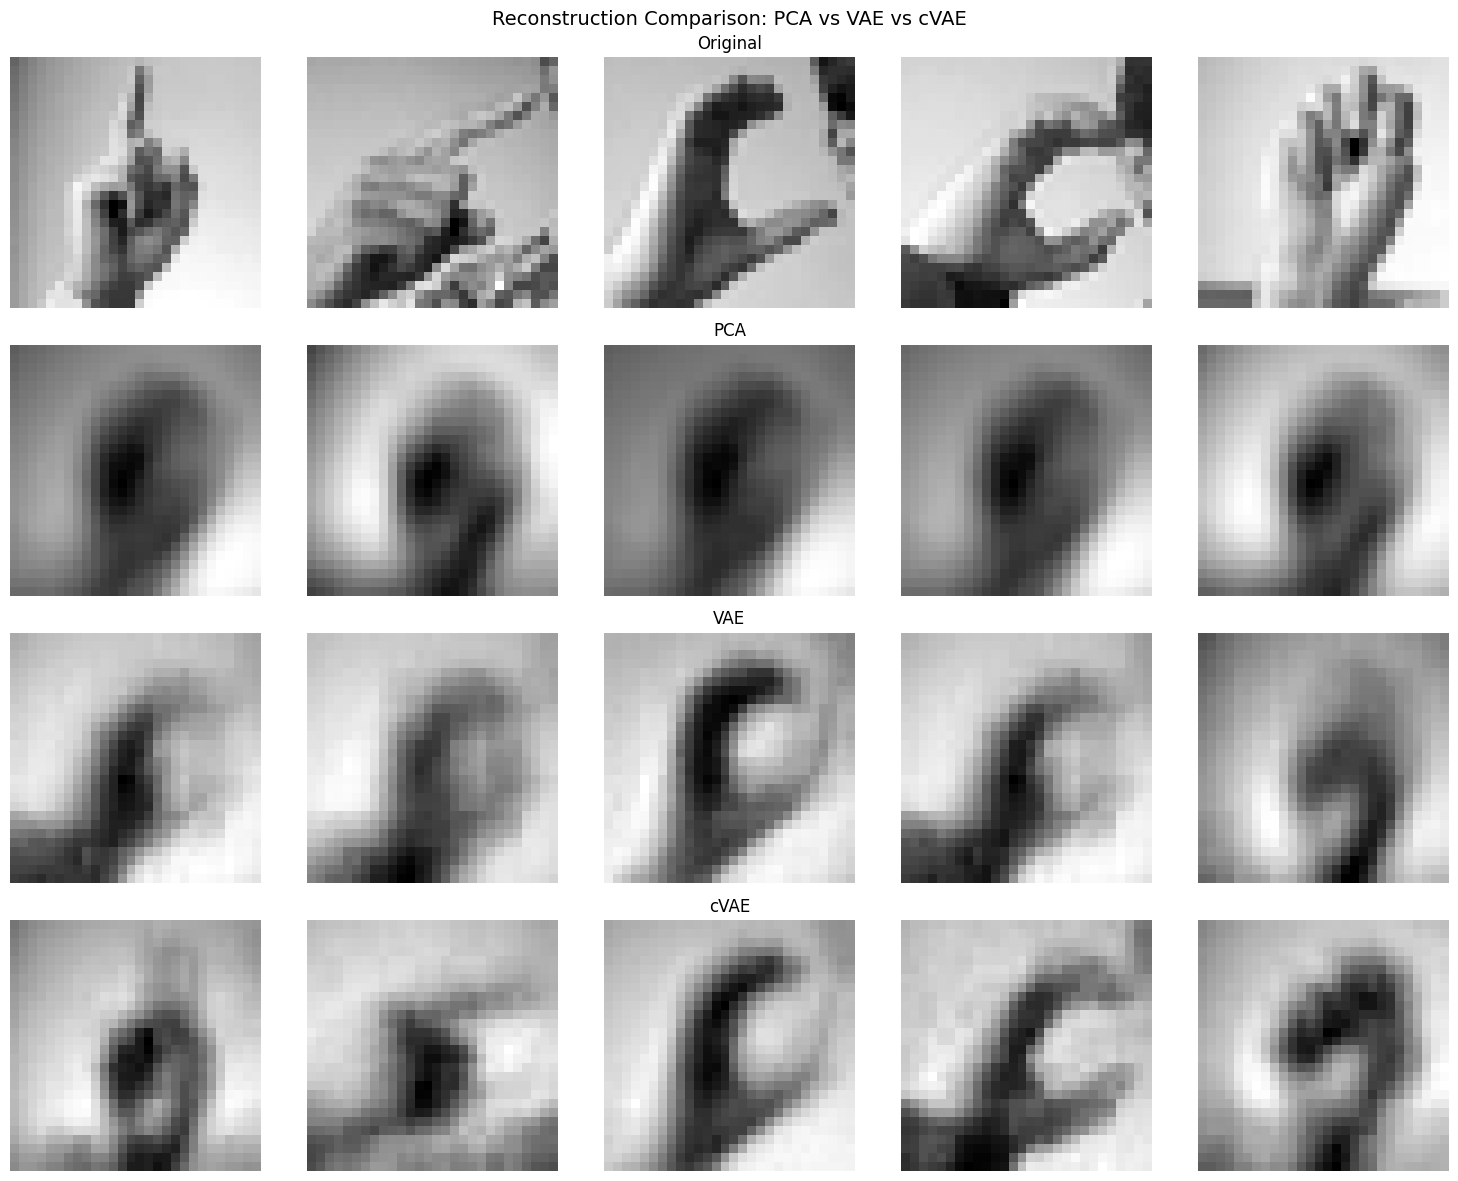

In [28]:
# PCA ανακατασκευή
X_pca_reconstructed = pca.inverse_transform(X_pca)
X_pca_reconstructed = X_pca_reconstructed.reshape(-1, 1, 28, 28)

# VAE και cVAE ανακατασκευή
vae.eval()
cvae.eval()

with torch.no_grad():
    sample = X_tensor[:5].to(device)
    labels_sample = y_tensor[:5].to(device)
    
    vae_recon, _, _ = vae(sample)
    cvae_recon, _, _ = cvae(sample, labels_sample)

# Plot
fig, axes = plt.subplots(4, 5, figsize=(15, 12))
titles = ['Original', 'PCA', 'VAE', 'cVAE']

for col in range(5):
    # Original
    axes[0, col].imshow(sample[col].cpu().squeeze(), cmap='gray')
    axes[0, col].set_title('Original' if col == 2 else '')
    axes[0, col].axis('off')
    
    # PCA
    axes[1, col].imshow(X_pca_reconstructed[col].squeeze(), cmap='gray')
    axes[1, col].set_title('PCA' if col == 2 else '')
    axes[1, col].axis('off')
    
    # VAE
    axes[2, col].imshow(vae_recon[col].cpu().squeeze(), cmap='gray')
    axes[2, col].set_title('VAE' if col == 2 else '')
    axes[2, col].axis('off')
    
    # cVAE
    axes[3, col].imshow(cvae_recon[col].cpu().squeeze(), cmap='gray')
    axes[3, col].set_title('cVAE' if col == 2 else '')
    axes[3, col].axis('off')

plt.suptitle('Reconstruction Comparison: PCA vs VAE vs cVAE', fontsize=14)
plt.tight_layout()
plt.show()

# Ποιοτική Σύγκριση:
**PCA:**
Πολύ θολές εικόνες
Όλες μοιάζουν σχεδόν ίδιες — χάνεται η ατομικότητα κάθε χειρονομίας
Λογικό γιατί εξηγεί μόνο το 40.8% της variance

**VAE:**
Καλύτερες από PCA — διακρίνονται κάποια σχήματα χεριών
Ακόμα θολές αλλά πιο διαφοροποιημένες μεταξύ τους

**cVAE:**
Καλύτερες από VAE — πιο ξεκάθαρα σχήματα
Η χρήση των labels βοηθάει να ανακατασκευαστούν πιο σωστές χειρονομίες

*Συμπέρασμα:*
`cVAE` > `VAE` > `PCA`

In [29]:
# 1. PCA - ήδη έχουμε το X_pca (27455, 2)

# 2. VAE latent representations
def get_vae_latent(model, X_tensor):
    model.eval()
    with torch.no_grad():
        _, mean, _ = model(X_tensor.to(device))
    return mean.cpu().numpy()  # Χρησιμοποιούμε το mean (όχι το z)

# 3. cVAE latent representations
def get_cvae_latent(model, X_tensor, y_tensor):
    model.eval()
    with torch.no_grad():
        _, mean, _ = model(X_tensor.to(device), y_tensor.to(device))
    return mean.cpu().numpy()

X_vae_latent = get_vae_latent(vae, X_tensor)
X_cvae_latent = get_cvae_latent(cvae, X_tensor, y_tensor)

print(f"PCA shape:  {X_pca.shape}")
print(f"VAE shape:  {X_vae_latent.shape}")
print(f"cVAE shape: {X_cvae_latent.shape}")

PCA shape:  (27455, 2)
VAE shape:  (27455, 2)
cVAE shape: (27455, 2)


In [30]:
y_np = y.values

representations = {
    'PCA': X_pca,
    'VAE': X_vae_latent,
    'cVAE': X_cvae_latent
}

for name, X_lat in representations.items():
    print(f"\n=== Classification - {name} ===")
    
    # Split
    X_lat_train, X_lat_val, y_lat_train, y_lat_val = train_test_split(
        X_lat, y_np, test_size=0.2, random_state=42, stratify=y_np
    )
    
    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, max_depth=None, random_state=42)
    rf.fit(X_lat_train, y_lat_train)
    y_pred = rf.predict(X_lat_val)
    
    # Metrics
    acc = accuracy_score(y_lat_val, y_pred)
    prec = precision_score(y_lat_val, y_pred, average='weighted')
    rec = recall_score(y_lat_val, y_pred, average='weighted')
    f1 = f1_score(y_lat_val, y_pred, average='weighted')
    
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")


=== Classification - PCA ===
Accuracy:  0.3661
Precision: 0.3640
Recall:    0.3661
F1 Score:  0.3645

=== Classification - VAE ===
Accuracy:  0.3763
Precision: 0.3753
Recall:    0.3763
F1 Score:  0.3755

=== Classification - cVAE ===
Accuracy:  0.2331
Precision: 0.2330
Recall:    0.2331
F1 Score:  0.2326


# Παρατηρήσεις:
`PCA` vs `VAE`: Παρόμοια απόδοση — το VAE είναι ελαφρώς καλύτερο (37.6% vs 36.6%)
cVAE χειρότερο από VAE: Ο λόγος είναι ότι το cVAE χρησιμοποιεί τα labels κατά το training — οπότε ο latent space εξαρτάται από τα labels. Αυτό σημαίνει ότι χωρίς τα labels στο inference, ο classifier δυσκολεύεται.

Γενικό συμπέρασμα:
Όλες οι μέθοδοι έχουν χαμηλή απόδοση με M=2 — πολύ λίγες διαστάσεις για 24 κλάσεις.

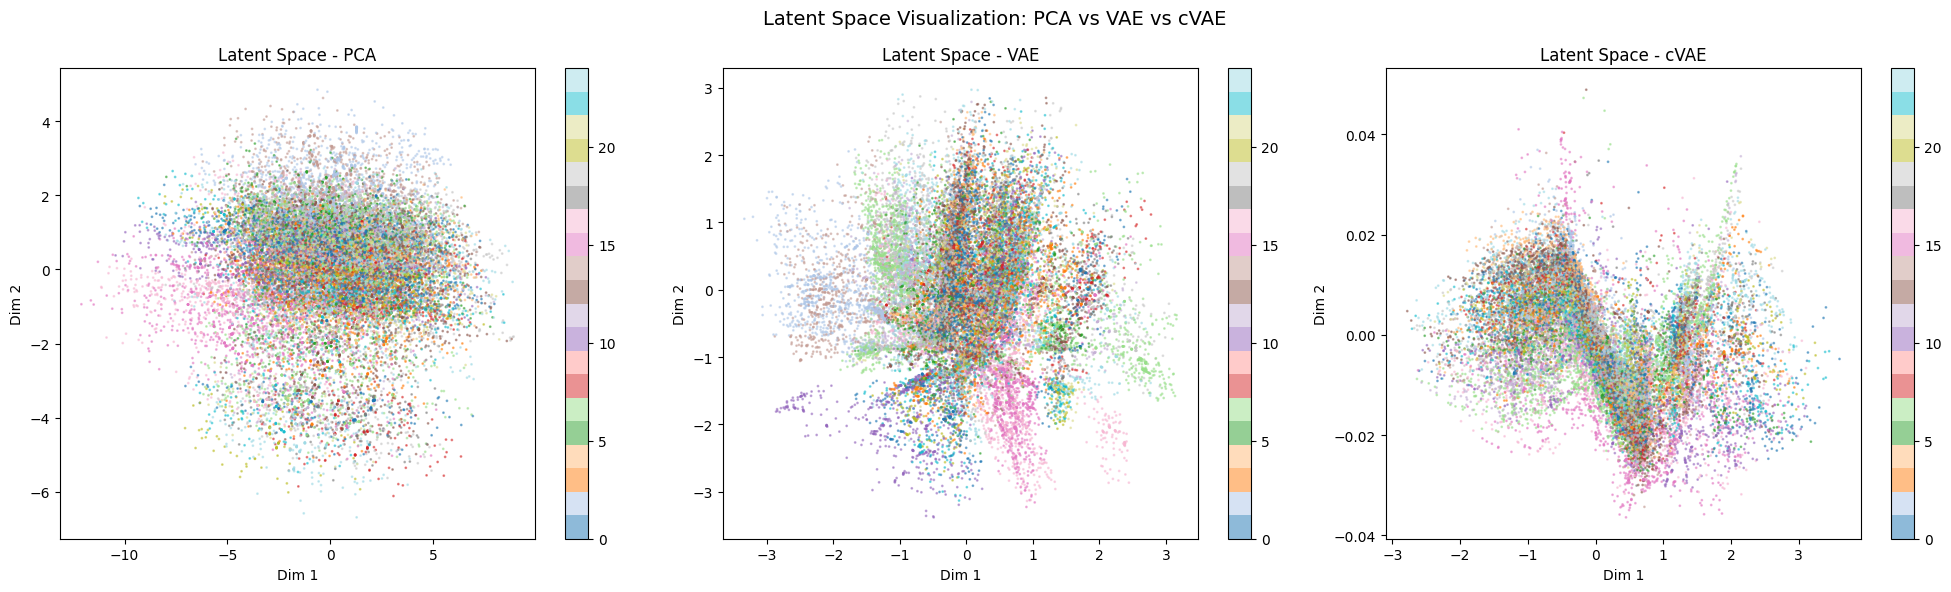

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

representations_plot = {
    'PCA': X_pca,
    'VAE': X_vae_latent,
    'cVAE': X_cvae_latent
}

for idx, (name, X_lat) in enumerate(representations_plot.items()):
    scatter = axes[idx].scatter(X_lat[:, 0], X_lat[:, 1],
                                c=y_np, cmap='tab20', s=1, alpha=0.5)
    axes[idx].set_title(f'Latent Space - {name}')
    axes[idx].set_xlabel('Dim 1')
    axes[idx].set_ylabel('Dim 2')
    plt.colorbar(scatter, ax=axes[idx])

plt.suptitle('Latent Space Visualization: PCA vs VAE vs cVAE', fontsize=14)
plt.tight_layout()
plt.show()

**PCA:**
Τα δεδομένα είναι διασκορπισμένα σε ένα oval σχήμα
Δεν υπάρχουν ξεκάθαρα clusters — όλες οι κλάσεις αναμεμειγμένες
Αντικατοπτρίζει το χαμηλό 40.8% variance που εξηγεί

**VAE:**
Βλέπουμε "ακτίνες" που εκτείνονται από το κέντρο
Κάποιες κλάσεις αρχίζουν να διαχωρίζονται σε διαφορετικές κατευθύνσεις
Πιο οργανωμένος από το PCA αλλά όχι τέλειος

**cVAE:**
Πολύ συμπιεσμένος χώρος (τιμές -0.04 έως 0.04)
Βλέπουμε 2 ξεκάθαρες "φτερούγες" — ο latent space έχει διαφορετική δομή
Αυτό συμβαίνει γιατί ο encoder "βασίζεται" στα labels για να οργανώσει τον latent space

*Γενικό συμπέρασμα:*
- Οργάνωση latent space: cVAE > VAE > PCA
- Χρησιμότητα για classification: VAE > PCA > cVAE

# **Γιατί το latent space του VAE είναι πιο κατάλληλο για clustering από του AE:**

**Ο κανονικός AE:**

- Ο Encoder μαθαίνει να αντιστοιχεί κάθε εικόνα σε ένα συγκεκριμένο σημείο στον latent space
- Δεν υπάρχει κανένας constraint — τα σημεία μπορούν να είναι οπουδήποτε
- Αποτέλεσμα: ο latent space έχει "τρύπες" — περιοχές χωρίς νόημα μεταξύ των clusters
- Φαίνεται αυτό στα plots — "ακτίνες" που εκτείνονται άτακτα


**Ο VAE:**

- Ο Encoder μαθαίνει να αντιστοιχεί κάθε εικόνα σε κατανομή N(μ, σ²)
- Το KL Divergence αναγκάζει όλες τις κατανομές να είναι κοντά στο N(0,I)
- Αποτέλεσμα: ο latent space είναι συνεχής και οργανωμένος — δεν έχει τρύπες
- Παρόμοιες εικόνες → κοντινά σημεία στον latent space


- `AE:`  Εικόνα → Σημείο (άτακτο)
- `VAE:` Εικόνα → Κατανομή (οργανωμένη γύρω από N(0,I))

**Ο `VAE` έχει smoother και denser latent space — ιδανικό για clustering γιατί:**

- Δεν υπάρχουν κενά μεταξύ clusters
- Παρόμοιες εικόνες είναι εγγυημένα κοντά μεταξύ τους
- Τα clusters είναι πιο compact και διαχωρισμένα